In [1]:

!pip install lightning -q
import lightning as L
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import timm
import torch.nn.functional as F
import torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 19.3 MB/s eta 0:00:0000:01


# Загрузка Датасета, Даталоадеры

In [2]:
class FashionMNISTDataModule(L.LightningDataModule):
    def __init__(self, data_dir="./data", batch_size=64, subset_size=None):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.subset_size = subset_size

        self.transform_train = transforms.Compose([
            transforms.Pad(2),
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.2860, 0.2860, 0.2860], std=[0.3530, 0.3530, 0.3530])
        ])

        self.transform_test = transforms.Compose([
            transforms.Pad(2),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.2860, 0.2860, 0.2860], std=[0.3530, 0.3530, 0.3530])
        ])

    def prepare_data(self):
        torchvision.datasets.FashionMNIST(self.data_dir, train=True, download=True)
        torchvision.datasets.FashionMNIST(self.data_dir, train=False, download=True)

    def setup(self, stage=None):
        self.train_set = torchvision.datasets.FashionMNIST(
            self.data_dir, train=True, transform=self.transform_train
        )
        self.test_set = torchvision.datasets.FashionMNIST(
            self.data_dir, train=False, transform=self.transform_test
        )
        if self.subset_size:
            self.train_set = Subset(self.train_set, range(self.subset_size))

    def train_dataloader(self):
        return DataLoader(
            self.train_set, batch_size=self.batch_size, shuffle=True,
            num_workers=2, pin_memory=True, persistent_workers=True
        )

    def val_dataloader(self):
        return DataLoader(
            self.test_set, batch_size=self.batch_size, shuffle=False,
            num_workers=2, pin_memory=True, persistent_workers=True
        )

fashion_dm = FashionMNISTDataModule()

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]


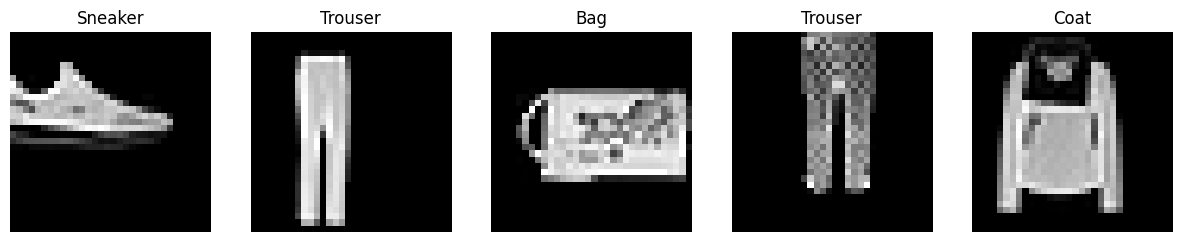

In [3]:
fashion_dm.prepare_data()
fashion_dm.setup()

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

loader = DataLoader(fashion_dm.train_set, batch_size=5, shuffle=True)
images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * 0.3530 + 0.2860
    axes[i].imshow(img.clip(0, 1))
    axes[i].set_title(classes[labels[i].item()])
    axes[i].axis('off')

plt.show()

# Загрузка модели

In [4]:
class ViTTinyClassifier(L.LightningModule):
    def __init__(self, num_classes=10, lr=1e-3, weight_decay=1e-4, max_epochs=10):
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model(
            'vit_tiny_patch16_224', pretrained=False,
            num_classes=num_classes, in_chans=3, img_size=32, patch_size=4
        )

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, on_epoch=True)
        self.log("train_acc", acc, on_epoch=True)
        self.log("lr", self.trainer.optimizers[0].param_groups[0]["lr"], on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, on_epoch=True, sync_dist=True)
        self.log("val_acc", acc, on_epoch=True, sync_dist=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.hparams.max_epochs
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"},
        }

# Обучение

In [5]:
model = ViTTinyClassifier(num_classes=10, lr=1e-3, weight_decay=1e-4, max_epochs=10)
trainer = L.Trainer(
    devices=1,
    max_epochs=10,
    accelerator="auto",
    precision="16-mixed",
)
trainer.fit(model, datamodule=fashion_dm)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ VisionTransformer │  5.4 M │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 5.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.4 M                                                                                                
Total estimated model params size (MB): 21.451                                                                     
Modules in train mode: 276                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=10` reached.


In [6]:
torch.save(model.cpu().state_dict(), 'vit_t_fashion.pth')